# 02 — Cálculo de \(D_{cp}(\omega,T_c)\)

Implementación de la ecuación (5) de la guía para **Al, Nb, Ta, Hg y Pb**. El cálculo se ejecuta automáticamente para todos los materiales disponibles.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT=Path.cwd().resolve()
if ROOT.name=="notebooks": ROOT=ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))

from src.io import read_eliashberg, read_phonon_dos, read_electronic_dos
from src.preprocessing import (
    preprocess_eliashberg,
    preprocess_phonon_dos,
    preprocess_electronic_dos
)

# ============================================================
# MATERIALES
# ============================================================
MATERIALES = ["Al", "Hg", "Nb", "Ta", "Pb"]

# ============================================================
# TEMPERATURA CRÍTICA Tc [K]
# ============================================================
TC_K = {
    "Al": 1.18,
    "Hg": 4.154,
    "Nb": 9.25,
    "Ta": 4.47,
    "Pb": 7.19
}

# ============================================================
# Constante de Boltzmann
# kB = 8.617333262e-2 meV/K
# ============================================================
kB_meV_K = 8.617333262e-2

# ============================================================
# Número de puntos para las mallas
# ============================================================
N_OMEGA = 500
N_E = 1200


## 1. Modelo numérico

\[
D_{cp}=\alpha^2(\omega)g_p^{n+1}g_p^n A(\omega)B(\omega),
\]

con

\[
A=\int_{-\omega_c}^{\omega_c}g_e^o(\epsilon)g_e^v(\epsilon-\omega)d\epsilon,
\quad
B=\int_{-\omega_c}^{\omega_c}g_e^o(\epsilon')g_e^v(\epsilon'+\omega)d\epsilon'.
\]

Se usa \(\alpha^2=\alpha^2F/N_{ph}\), evitando la división cuando \(N_{ph}=0\).

In [2]:
def fermi(x, beta):
    z = np.clip(beta * np.asarray(x), -700, 700)
    return 1 / (np.exp(z) + 1)

def bose(w, beta):
    if w <= 0:
        return 0.0
    return 1 / np.expm1(np.clip(beta * w, -700, 700))

def calculate_material(mat):
    folder = ROOT / "data" / "raw" / mat

    a = read_eliashberg(folder / f"{mat}_alpha2F.csv")
    ph = read_phonon_dos(folder / f"{mat}_DOS_fonones.csv")
    el = read_electronic_dos(folder / f"{mat}_DOS_electronica.csv")

    # Eliashberg robusto: automático y fallback si no hay alpha^2F=0 exacto
    try:
        eli = preprocess_eliashberg(a["frequency_mev"], a["a2f_total"])
        wc = float(eli["omega_c_mev"])
    except ValueError as err:
        if "No se encontró un punto con alpha^2F = 0" not in str(err):
            raise

        freq = np.asarray(a["frequency_mev"], dtype=float)
        a2f_raw = np.asarray(a["a2f_total"], dtype=float)

        m = (
            np.isfinite(freq)
            & np.isfinite(a2f_raw)
            & (freq >= 0.0)
            & (a2f_raw >= 0.0)
        )
        freq = freq[m]
        a2f_raw = a2f_raw[m]

        if freq.size == 0:
            raise ValueError(f"{mat}: sin datos válidos de Eliashberg.")

        order = np.argsort(freq)
        freq = freq[order]
        a2f_raw = a2f_raw[order]

        wc = float(freq[-1])
        eli = {
            "frequency_mev": freq,
            "a2f_total": a2f_raw,
            "omega_c_mev": wc,
        }

    p = preprocess_phonon_dos(
        ph["frequency_mev"],
        ph["dos"],
        omega_c_mev=wc,
    )

    # Datos electrónicos limpios (NO usar recorte degenerado para integrar)
    eps_raw = np.asarray(el["epsilon_mev"], dtype=float)
    dos_raw = np.asarray(el["dos"], dtype=float)

    m_el = np.isfinite(eps_raw) & np.isfinite(dos_raw)
    eps_raw = eps_raw[m_el]
    dos_raw = dos_raw[m_el]

    if eps_raw.size == 0:
        raise ValueError(f"{mat}: epsilon_mev vacío o inválido.")

    # Mantener preprocess solo para reporte de cutoff electrónico
    abs_eps = np.abs(eps_raw)
    pos_abs_eps = abs_eps[abs_eps > 0.0]
    if pos_abs_eps.size == 0:
        raise ValueError(f"{mat}: epsilon_mev solo contiene 0.")

    wc_el = float(min(wc, np.max(abs_eps)))
    wc_el_min = float(np.min(pos_abs_eps))
    if wc_el < wc_el_min:
        wc_el = wc_el_min

    _ = preprocess_electronic_dos(
        eps_raw,
        dos_raw,
        omega_c_mev=wc_el,
    )

    wa = np.linspace(0.0, wc, N_OMEGA)

    # Usar malla electrónica completa y ordenada (evita colapso a 1 punto)
    order_el = np.argsort(eps_raw)
    eps = eps_raw[order_el]
    ne = dos_raw[order_el]

    # DOS físico no negativo + normalización
    ne = np.maximum(ne, 0.0)
    ne_max = float(np.max(ne))
    if ne_max <= 0.0:
        raise ValueError(f"{mat}: DOS electrónico no positivo.")
    ne = ne / ne_max

    a2f = np.interp(wa, eli["frequency_mev"], eli["a2f_total"], left=0.0, right=0.0)
    nph = np.interp(wa, p["frequency_mev"], p["dos"], left=0.0, right=0.0)

    alpha2_grid = np.divide(
        a2f,
        nph,
        out=np.zeros_like(a2f),
        where=nph > 0.0,
    )

    beta = 1 / (kB_meV_K * TC_K[mat])

    D = np.zeros_like(wa)
    A = np.zeros_like(wa)
    B = np.zeros_like(wa)

    def Ne(x):
        y = np.interp(x, eps, ne, left=0.0, right=0.0)
        return np.maximum(y, 1e-12)

    f_occ = np.clip(fermi(eps, beta), 1e-12, 1.0 - 1e-12)
    go_eps = np.maximum(ne, 1e-12) * f_occ

    for j, w in enumerate(wa):
        if w <= 0.0:
            continue

        alpha2 = alpha2_grid[j]

        f_m = np.clip(fermi(eps - w, beta), 1e-12, 1.0 - 1e-12)
        f_p = np.clip(fermi(eps + w, beta), 1e-12, 1.0 - 1e-12)

        gv_m = Ne(eps - w) * (1.0 - f_m)
        gv_p = Ne(eps + w) * (1.0 - f_p)

        A[j] = np.trapezoid(go_eps * gv_m, eps)
        B[j] = np.trapezoid(go_eps * gv_p, eps)

        n = max(bose(w, beta), 1e-12)
        D[j] = alpha2 * (n + 1.0) * n * A[j] * B[j]

    i = int(np.argmax(D))
    omega_cp = float(wa[i])
    Ncp = float(np.trapezoid(D, wa))

    if mat == "Pb":
        print("Pb debug:")
        print("eps min/max:", float(np.min(eps)), float(np.max(eps)))
        print("max ne(norm):", float(np.max(ne)))
        print("max go_eps:", float(np.max(go_eps)))
        print("max A:", float(np.max(A)), "max B:", float(np.max(B)))
        print("max alpha2:", float(np.max(alpha2_grid)))
        print("nonzero A:", int(np.count_nonzero(A)), "nonzero B:", int(np.count_nonzero(B)))
        print("nonzero D:", int(np.count_nonzero(D)))

    return {
        "material": mat,
        "Tc_K": TC_K[mat],
        "omega": wa,
        "Dcp": D,
        "A": A,
        "B": B,
        "omega_c": wc,
        "omega_c_el": wc_el,
        "omega_cp": omega_cp,
        "Dcp_max": float(D[i]),
        "Ncp": Ncp,
        "a2f_grid": a2f,
        "nph_grid": nph,
        "alpha2_grid": alpha2_grid,
        "eps_grid": eps,
        "ne_grid": ne,
    }

In [3]:
results = {}

for mat in MATERIALES:
    results[mat] = calculate_material(mat)
    r = results[mat]
    print(
        f"{mat}: Tc={r['Tc_K']:.2f} K | "
        f"omega_c={r['omega_c']:.4f} meV | "
        f"omega_c_el={r['omega_c_el']:.4f} meV | "
        f"omega_cp={r['omega_cp']:.4f} meV | "
        f"Ncp={r['Ncp']:.4e}"
    )

Al: Tc=1.18 K | omega_c=39.6762 meV | omega_c_el=39.6762 meV | omega_cp=0.0795 meV | Ncp=6.3307e-17
Hg: Tc=4.15 K | omega_c=11.3422 meV | omega_c_el=11.3422 meV | omega_cp=0.0227 meV | Ncp=3.1022e-10
Nb: Tc=9.25 K | omega_c=26.2484 meV | omega_c_el=26.2484 meV | omega_cp=0.0526 meV | Ncp=1.4583e-16
Ta: Tc=4.47 K | omega_c=20.6394 meV | omega_c_el=20.6394 meV | omega_cp=0.0414 meV | Ncp=4.2424e-04
Pb debug:
eps min/max: -18087.0 19913.0
max ne(norm): 1.0
max go_eps: 0.999999999999
max A: 3.7200070755472845e-10 max B: 3.7200065262282724e-10
max alpha2: 103.21467859188208
nonzero A: 499 nonzero B: 499
nonzero D: 498
Pb: Tc=7.19 K | omega_c=9.8706 meV | omega_c_el=13.0000 meV | omega_cp=0.0198 meV | Ncp=6.7409e-19


## 2. Resultados y gráficas

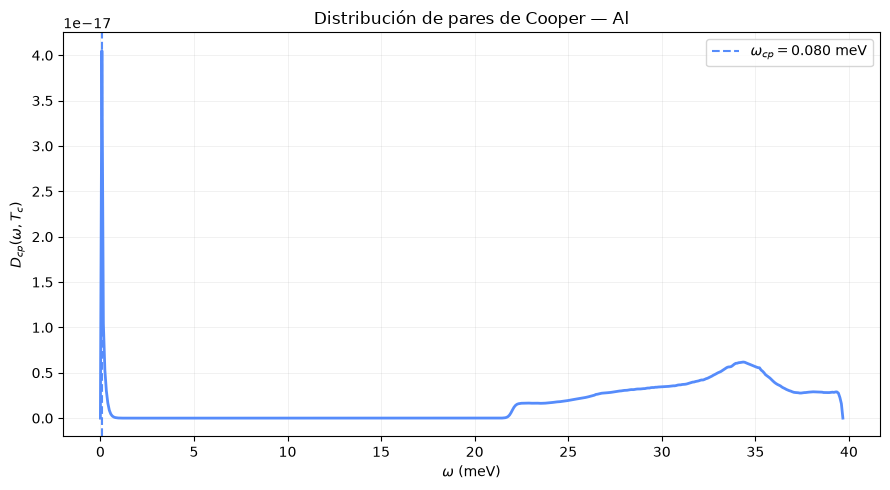

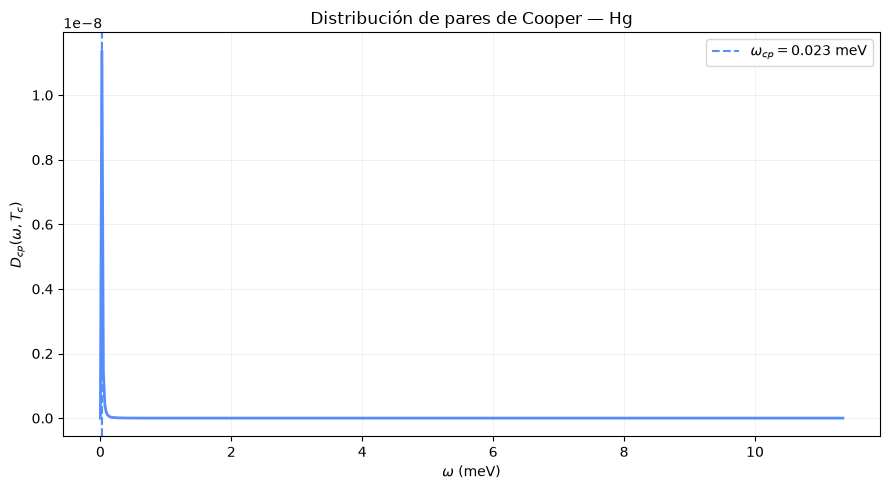

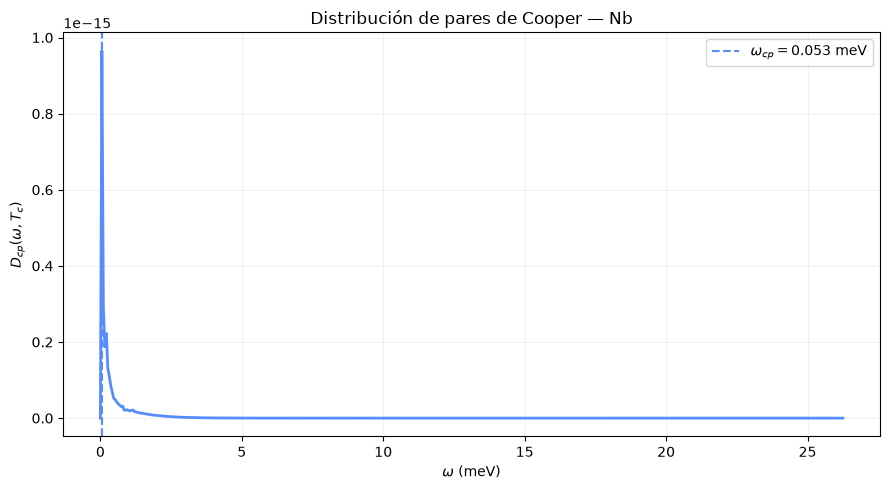

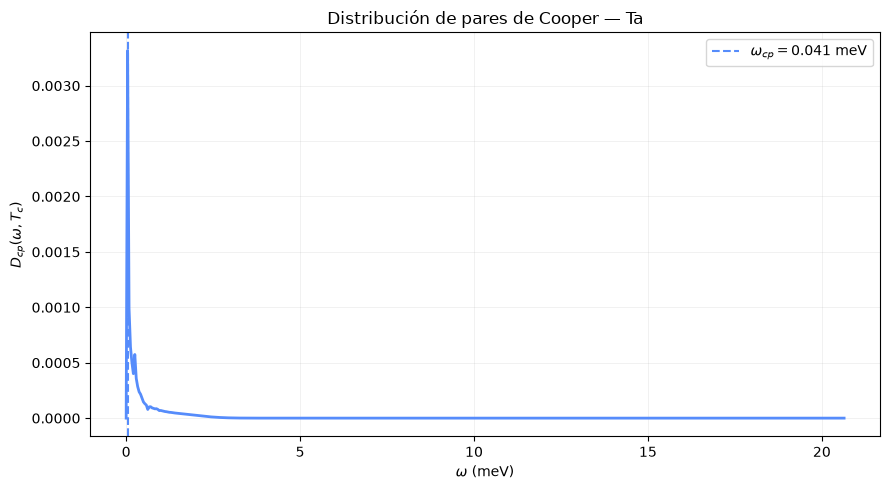

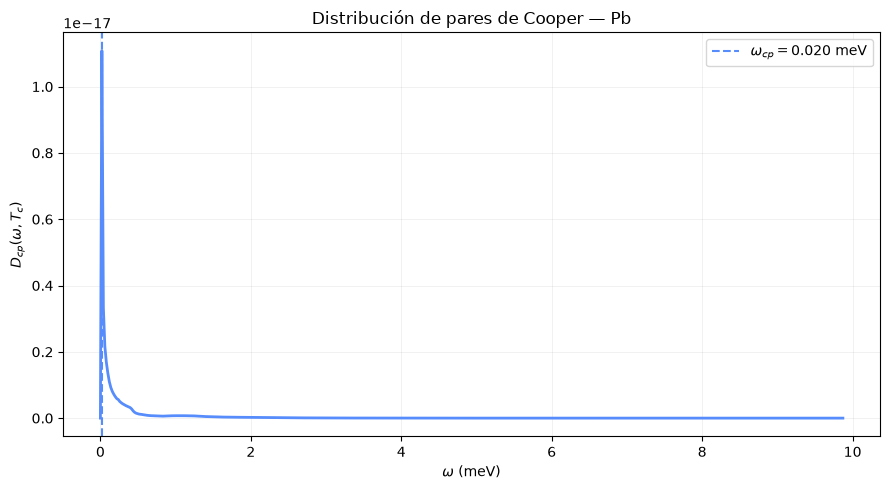

,material,Tc_K,omega_c_meV,omega_cp_meV,Dcp_max,Ncp
0,Al,1.180,39.676242,0.079512,4.050092e-17,6.330749e-17
1,Hg,4.154,11.342195,0.022730,1.137441e-08,3.102244e-10
2,Nb,9.250,26.248375,0.052602,9.654124e-16,1.458284e-16
3,Ta,4.470,20.639428,0.041362,3.315641e-03,4.242439e-04
4,Pb,7.190,9.870604,0.019781,1.108259e-17,6.740877e-19


In [4]:
TABLES=ROOT/"results"/"tables"; FIGS=ROOT/"results"/"figures"; TABLES.mkdir(parents=True,exist_ok=True); FIGS.mkdir(parents=True,exist_ok=True)
summary=[]
for mat,r in results.items():
    fig,ax=plt.subplots(figsize=(9,5)); ax.plot(r["omega"],r["Dcp"],linewidth=2); ax.axvline(r["omega_cp"],ls="--",label=fr"$\omega_{{cp}}={r['omega_cp']:.3f}$ meV"); ax.set(xlabel=r"$\omega$ (meV)",ylabel=r"$D_{cp}(\omega,T_c)$",title=f"Distribución de pares de Cooper — {mat}"); ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); fig.savefig(FIGS/f"{mat}_Dcp.png",dpi=300); plt.show()
    pd.DataFrame({"omega_meV":r["omega"],"Dcp":r["Dcp"],"A_electronica":r["A"],"B_electronica":r["B"]}).to_csv(TABLES/f"Dcp_{mat}.csv",index=False)
    summary.append({"material":mat,"Tc_K":r["Tc_K"],"omega_c_meV":r["omega_c"],"omega_cp_meV":r["omega_cp"],"Dcp_max":r["Dcp_max"],"Ncp":r["Ncp"]})
summary_df=pd.DataFrame(summary); summary_df.to_csv(TABLES/"Dcp_resumen.csv",index=False); display(summary_df)

## 3. Comprobaciones

Se verifica que \(D_{cp}\ge0\), \(D_{cp}(0)=0\) y \(0\le\omega_{cp}\le\omega_c\).

In [5]:
for mat,r in results.items():
    print(mat, "|", "OK" if np.all(r["Dcp"]>=-1e-12) and abs(r["Dcp"][0])<1e-12 and 0<=r["omega_cp"]<=r["omega_c"] else "REVISAR")

Al | OK
Hg | OK
Nb | OK
Ta | OK
Pb | OK
